# 03 - Spatial Clustering, Machine Learning & Metropolitan Analytics

This notebook presents the core modeling, unsupervised spatial clustering, and policy quadrant analytics for the **NCRB 2024 Big Data Analytics Project**.

### Analytical Highlights
- **Dimensionality Reduction**: 4 Principal Components explaining 67.4% of all-India crime variance.
- **Unsupervised Clustering**: K-Means ($k=5$) segmenting all 964 districts into distinct socio-legal typologies.
- **Anomaly Detection**: DBSCAN isolating 28 acute statistical outliers and specialized police wings.
- **Metropolitan Policy Quadrants**: 4-quadrant efficiency matrix mapping 37 million-plus cities on Crime Rate vs Chargesheeting Efficiency.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

sns.set_theme(style="whitegrid", palette="muted")

PROCESSED_DIR = Path("../data/processed")
OUTPUTS_DIR = Path("../outputs")
FIGURES_DIR = OUTPUTS_DIR / "figures"

print("Processed Directory:", PROCESSED_DIR.resolve())
print("Figures Directory  :", FIGURES_DIR.resolve())

Processed Directory: C:\Users\ayush\OneDrive\Desktop\Ayush\BDA Project\data\processed
Figures Directory  : C:\Users\ayush\OneDrive\Desktop\Ayush\BDA Project\outputs\figures


## 1. Load Clustered Datasets & Cluster Centroid Profiles

In [2]:
df_clusters = pd.read_parquet(PROCESSED_DIR / "district_clusters.parquet")
df_centroids = pd.read_csv(OUTPUTS_DIR / "cluster_profiles.csv")
df_quadrants = pd.read_parquet(PROCESSED_DIR / "metro_policing_quadrants.parquet")

print(f"Clustered Districts Dataset: {df_clusters.shape}")
print(f"Metropolitan Quadrants Dataset: {df_quadrants.shape}")

print("\n--- Typology Distribution Across Indian Districts ---")
typology_counts = df_clusters["typology_label"].value_counts().reset_index()
typology_counts.columns = ["Typology Name", "District Count"]
typology_counts["Percentage Share"] = (typology_counts["District Count"] / len(df_clusters) * 100).round(2)
display(typology_counts)

Clustered Districts Dataset: (964, 31)
Metropolitan Quadrants Dataset: (37, 18)

--- Typology Distribution Across Indian Districts ---


,Typology Name,District Count,Percentage Share
0,Agrarian Belts with Elevated Atrocity Reporting,577,59.85
1,High Violent Crime & Women Vulnerability Belts,170,17.63
2,Low-Intensity Stable Administrative Districts,153,15.87
3,Major Commercial & High Crime Burden Hubs,40,4.15
4,Specialized Investigation & Cyber Wings,24,2.49


## 2. Hyperparameter Optimization: Elbow & Silhouette Analysis
We display the elbow curve and silhouette score across $k \in [2, 8]$. $k=5$ optimizes the balance between intra-cluster cohesion and inter-cluster separation.

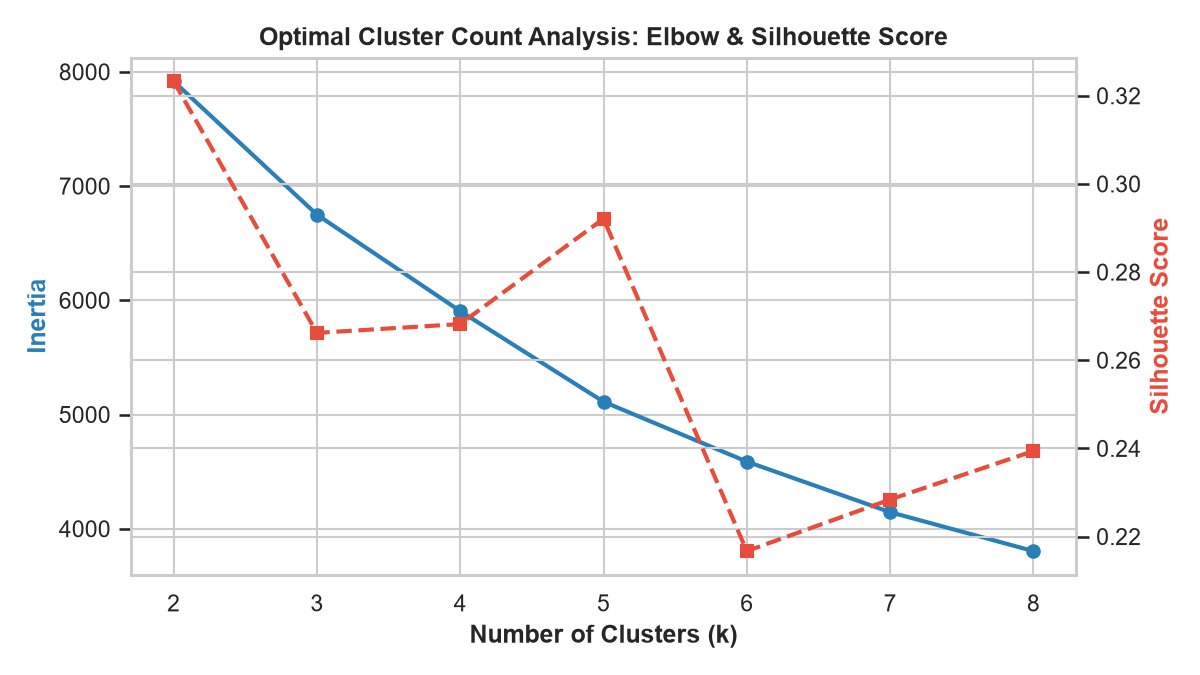

In [3]:
display(Image(filename=str(FIGURES_DIR / "elbow_silhouette_analysis.png")))

## 3. PCA 2D Cluster Biplot
Visualization of all 964 administrative districts projected along Principal Component 1 (25.2% variance) and Principal Component 2 (21.6% variance).

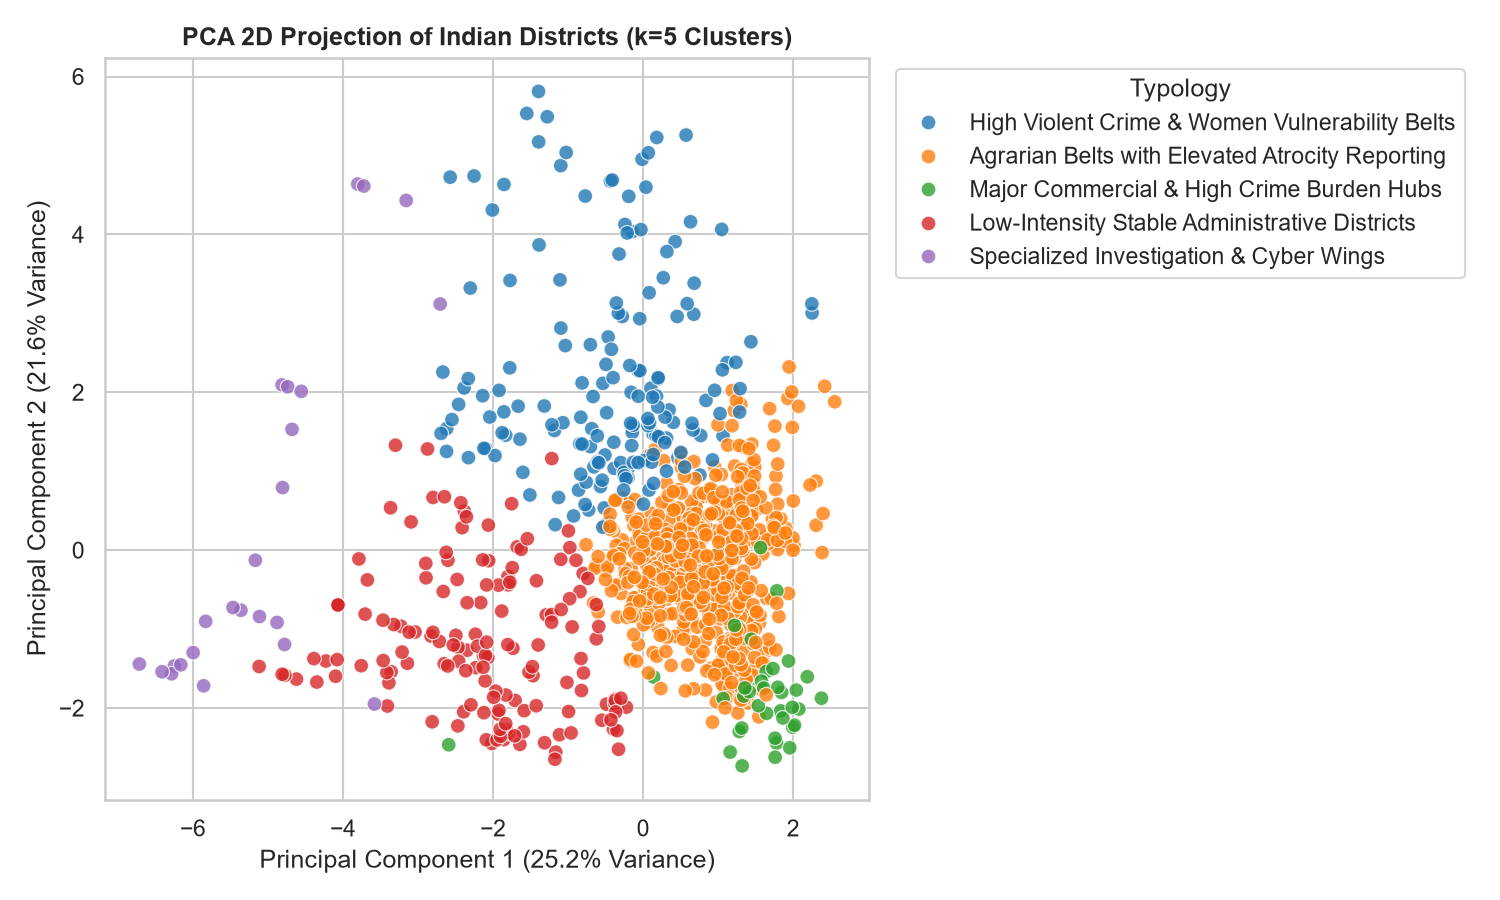

In [4]:
display(Image(filename=str(FIGURES_DIR / "pca_cluster_biplot.png")))

## 4. Typology Centroid Heatmap
Standardized z-score deviations highlighting the signature crime dimensions characterizing each national cluster.

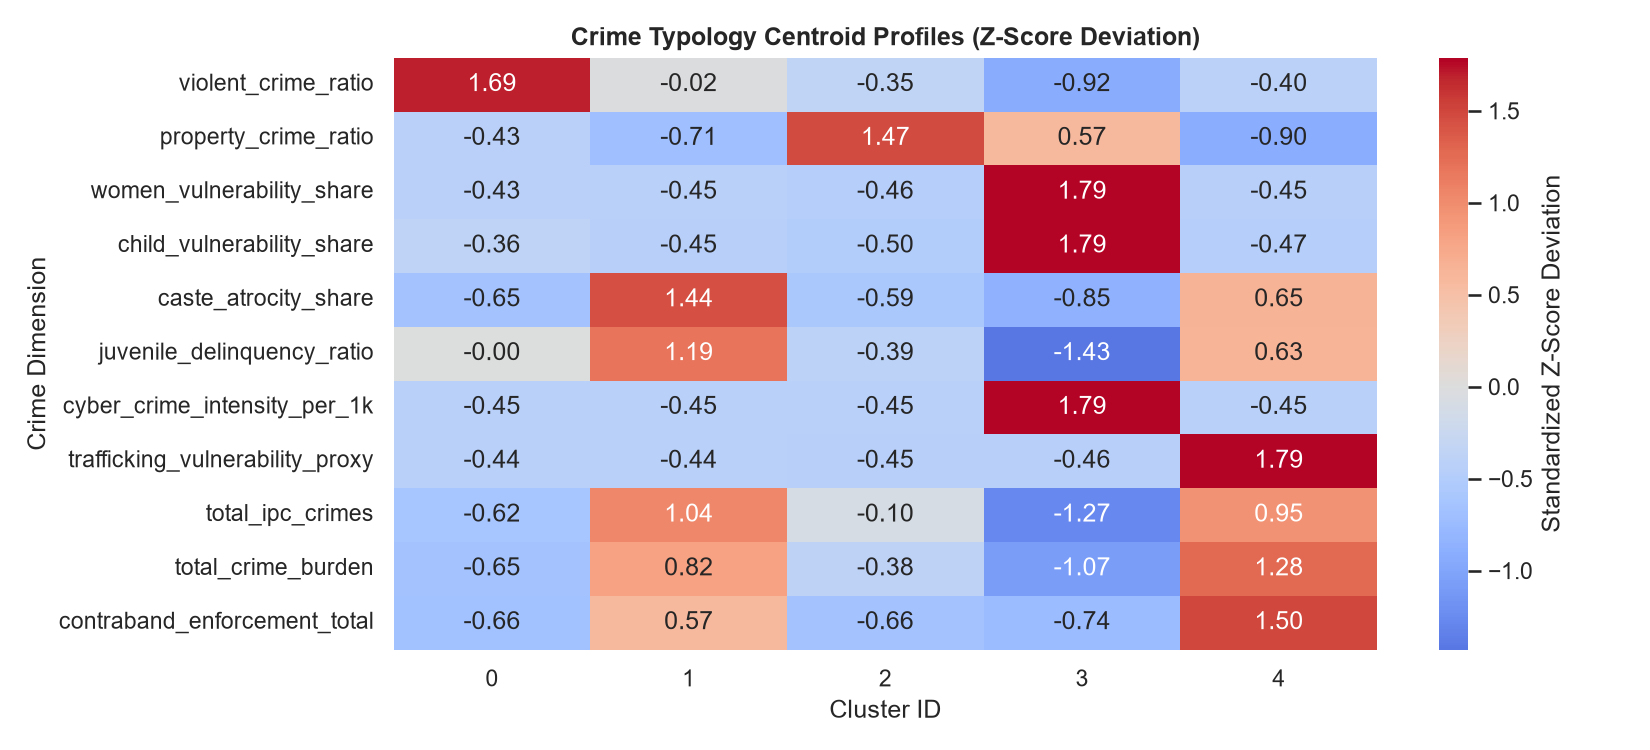

In [5]:
display(Image(filename=str(FIGURES_DIR / "district_cluster_profiles_heatmap.png")))

## 5. Metropolitan Policing Efficiency Quadrants
Categorizing 37 metropolitan cities on **Cognizable Crime Rate per Lakh** vs. **Chargesheeting Rate (%)** to identify high-performance vs. overburdened police systems.

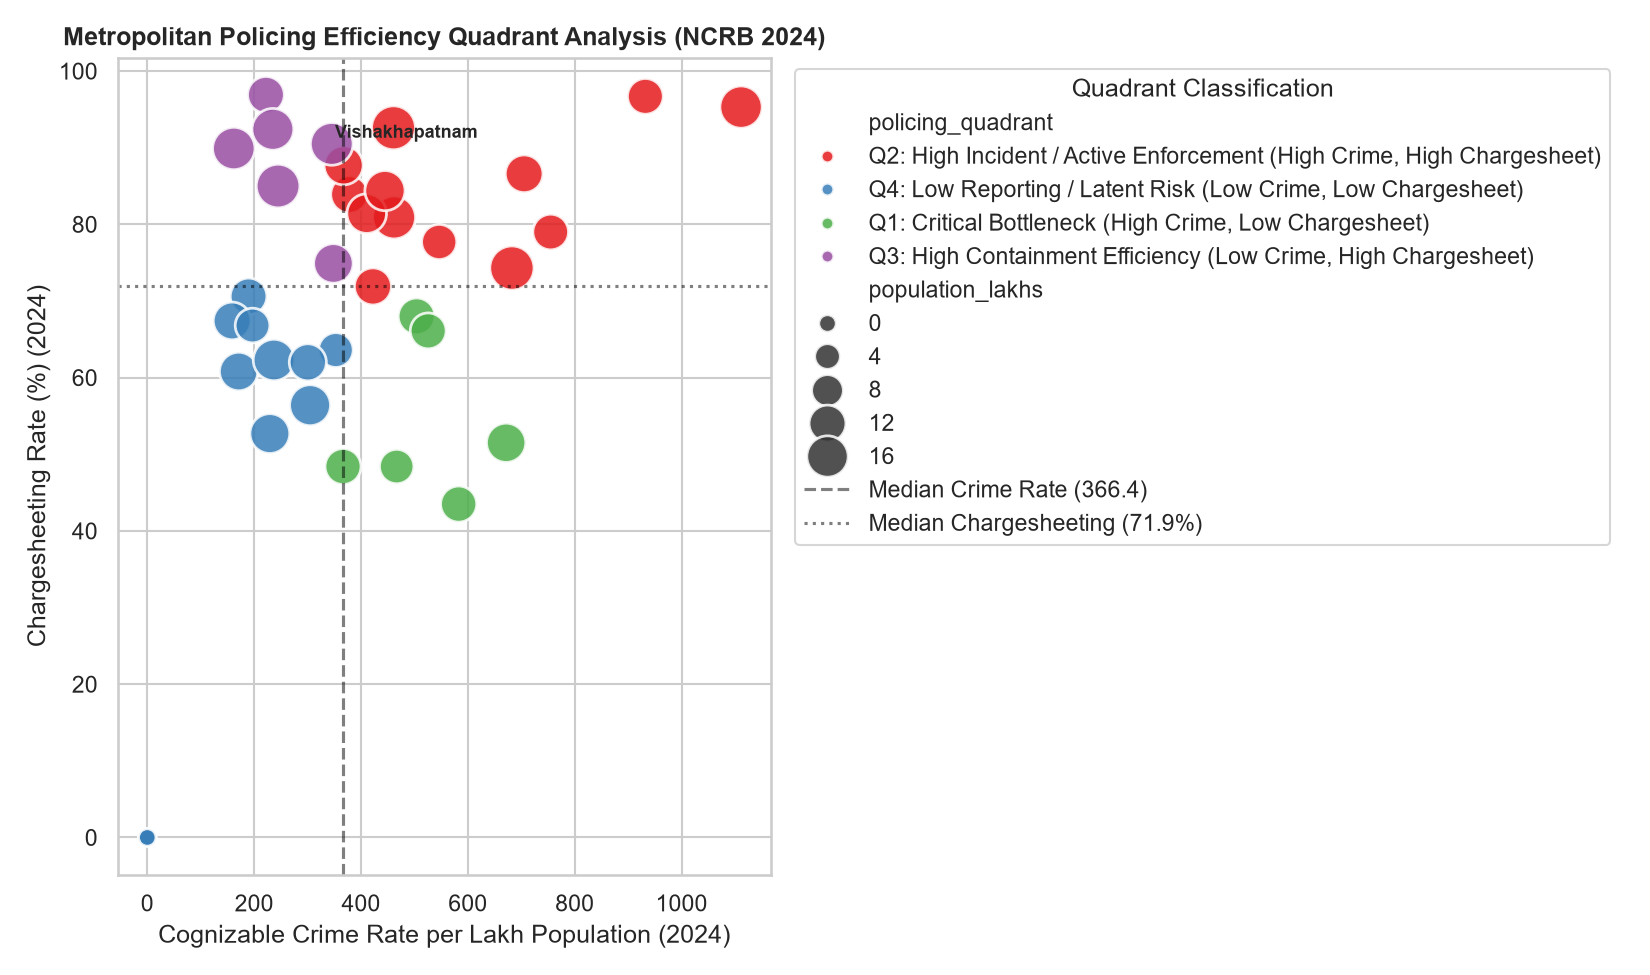

Metropolitan Cities Breakdown by Quadrant:

Q1: Critical Bottleneck (High Crime, Low Chargesheet) (6 cities):
   Chhatrapati Sambhajinagar, Faridabad, Jodhpur, Kota, Raipur, Ranchi

Q2: High Incident / Active Enforcement (High Crime, High Chargesheet) (13 cities):
   Agra, Asansol, Bhopal, Durg-Bhilainagar, Gwalior, Jabalpur, Kollam, Rajkot, Thiruvananthapuram, Thrissur, Varanasi, Vasai Virar, Ntr (Vijayawada)

Q3: High Containment Efficiency (Low Crime, High Chargesheet) (6 cities):
   Dhanbad, Kannur, Malappuram, Meerut, Vadodara, Vishakhapatnam

Q4: Low Reporting / Latent Risk (Low Crime, Low Chargesheet) (12 cities):
   Amritsar, Chandigarh City, Jamshedpur, Ludhiana, Madurai, Nasik, Prayagraj, Srinagar, Tiruchirapalli, +' Crime Rate Is Calculated As Crime Per One Lakh Of Population., ● As Per Data Provided By States/Uts, ● States/Uts/Cities May Not Be Compared Purely On The Basis Of Crime Figures


In [6]:
display(Image(filename=str(FIGURES_DIR / "metro_policing_efficiency_quadrant.png")))

# Summary table by Quadrant
print("Metropolitan Cities Breakdown by Quadrant:")
for q in sorted(df_quadrants["policing_quadrant"].unique()):
    cities = df_quadrants[df_quadrants["policing_quadrant"] == q]["city"].tolist()
    print(f"\n{q} ({len(cities)} cities):")
    print("  ", ", ".join(cities))

## 6. Qualitative Motive Decomposition: Murder & Cybercrime
Empirical ranking of behavioral drivers behind lethal violence and cyber attacks.

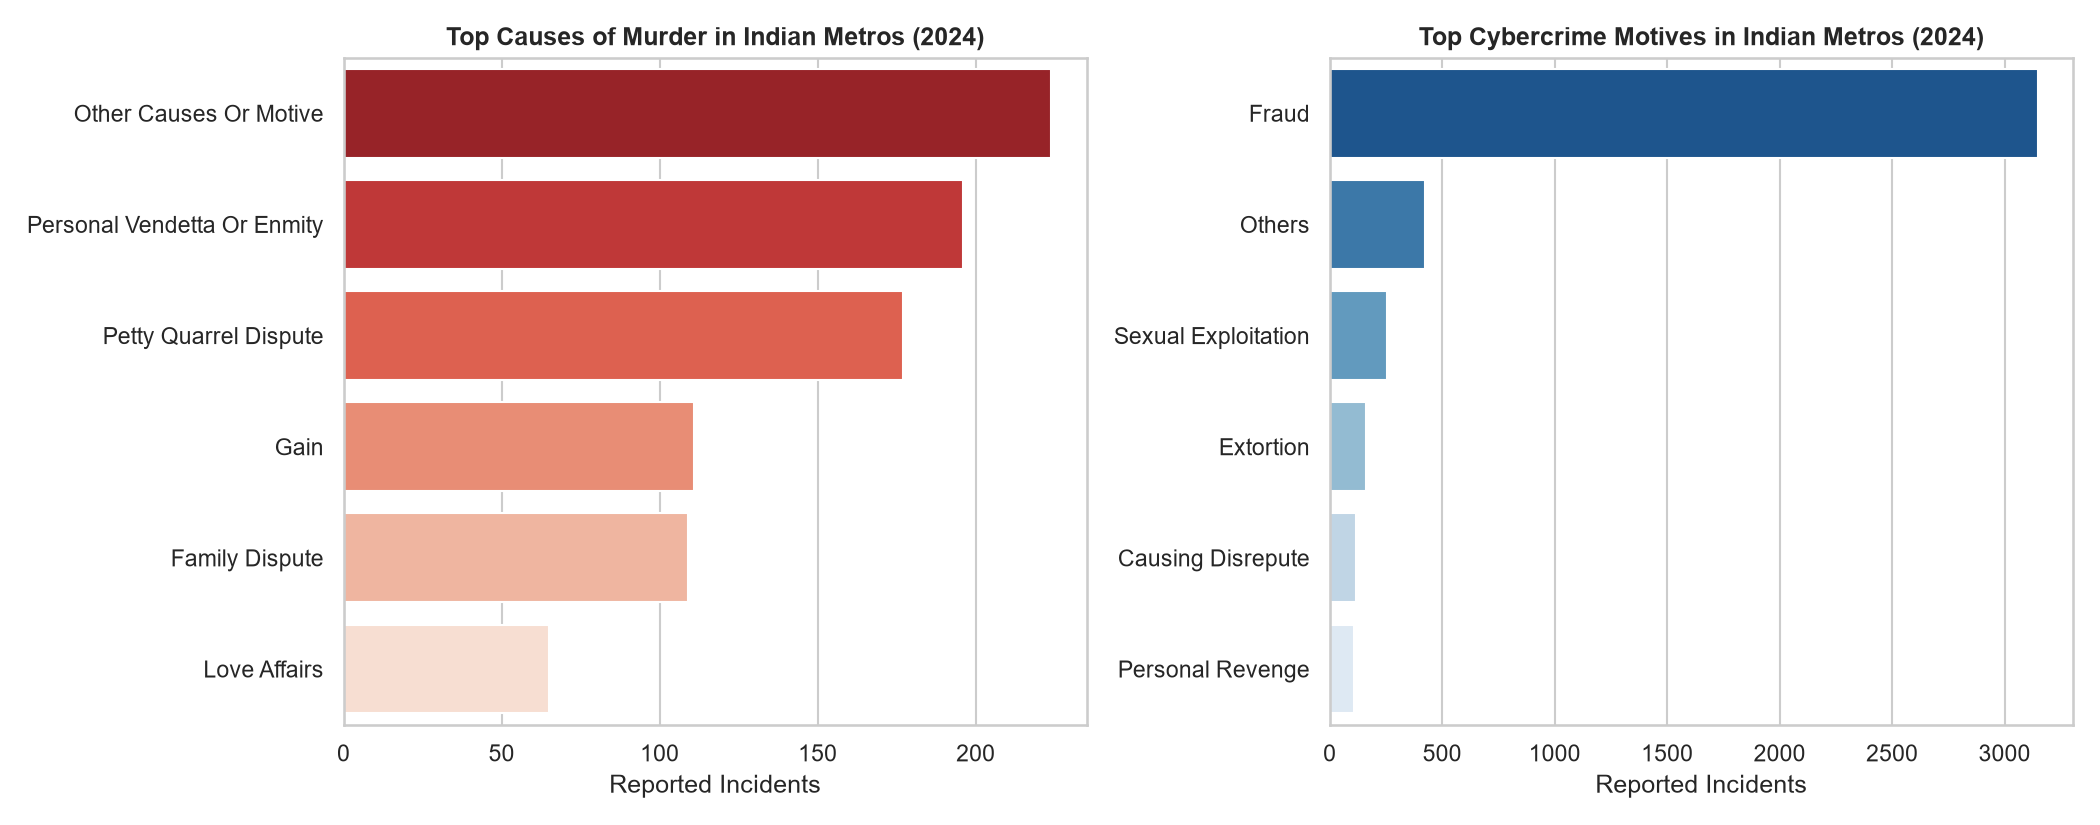

In [7]:
display(Image(filename=str(FIGURES_DIR / "top_murder_and_cyber_motives.png")))

## 7. Interactive District Typology Lookup
Search and inspect cluster classifications for selected states and districts.

In [8]:
def lookup_state_typologies(state_name: str):
    sub = df_clusters[df_clusters["state"].str.lower() == state_name.lower()]
    if sub.empty:
        print(f"No districts found for state '{state_name}'. Available states:")
        print(sorted(df_clusters["state"].unique()))
        return
    print(f"=== Typology Breakdown for {state_name.title()} ({len(sub)} units) ===")
    display(sub[["district", "typology_label", "total_ipc_crimes", "violent_crime_ratio", "women_vulnerability_share", "caste_atrocity_share", "is_anomaly"]].head(10))

# Demonstration lookup for Delhi and Maharashtra
lookup_state_typologies("Delhi")
lookup_state_typologies("Maharashtra")

=== Typology Breakdown for Delhi (23 units) ===


,district,typology_label,total_ipc_crimes,violent_crime_ratio,women_vulnerability_share,caste_atrocity_share,is_anomaly
184,Central,Low-Intensity Stable Administrative Districts,48744,0.0041,0.0375,0.0001,False
185,Crime Branch,Low-Intensity Stable Administrative Districts,306,0.0556,0.0131,0.0000,False
186,Dwarka,Low-Intensity Stable Administrative Districts,66340,0.0037,0.0603,0.0007,False
187,East,Low-Intensity Stable Administrative Districts,74156,0.0032,0.0351,0.0002,False
188,Eow,Low-Intensity Stable Administrative Districts,557,0.0000,0.0000,0.0000,False
189,Igi Airport,Low-Intensity Stable Administrative Districts,2713,0.0022,0.0247,0.0000,False
190,Metro,Low-Intensity Stable Administrative Districts,28593,0.0001,0.0027,0.0000,False
191,New Delhi,Low-Intensity Stable Administrative Districts,8539,0.0029,0.0378,0.0033,False
192,North,Low-Intensity Stable Administrative Districts,89162,0.0022,0.0238,0.0002,False
193,North-East,Low-Intensity Stable Administrative Districts,86255,0.0043,0.0460,0.0007,False


=== Typology Breakdown for Maharashtra (49 units) ===


,district,typology_label,total_ipc_crimes,violent_crime_ratio,women_vulnerability_share,caste_atrocity_share,is_anomaly
489,Ahilyanagar,Agrarian Belts with Elevated Atrocity Reporting,55992,0.0111,0.1313,0.0211,False
490,Akola,Agrarian Belts with Elevated Atrocity Reporting,17579,0.0068,0.1577,0.0139,False
491,Amravati Commr,Agrarian Belts with Elevated Atrocity Reporting,13880,0.0133,0.1438,0.0080,False
492,Amravati Rural,Agrarian Belts with Elevated Atrocity Reporting,25499,0.0077,0.1158,0.0147,False
493,Beed,Agrarian Belts with Elevated Atrocity Reporting,26374,0.0256,0.1748,0.0369,False
494,Bhandara,Agrarian Belts with Elevated Atrocity Reporting,10981,0.0076,0.0900,0.0113,False
495,Buldhana,Agrarian Belts with Elevated Atrocity Reporting,26980,0.0132,0.1208,0.0213,False
496,Chandrapur,Agrarian Belts with Elevated Atrocity Reporting,24229,0.0083,0.1097,0.0171,False
497,Chhatrapati Sambhajinagar Commr,Agrarian Belts with Elevated Atrocity Reporting,22343,0.0162,0.1580,0.0138,False
498,Chhatrapati Sambhajinagar Railway,Low-Intensity Stable Administrative Districts,13620,0.0012,0.0083,0.0000,False


## 8. Summary of Findings & Actionable Policy Insights
1. **Geographic Concentration of Vulnerability**: Gender-based violence and violent crime ratios cluster intensely in specific administrative zones (Cluster 1: 170 districts), requiring targeted fast-track courts.
2. **Specialized Police Units**: Cyber Crime Cells and State CID wings cluster into an independent outlier profile due to their institutional focus on non-IPC digital fraud.
3. **Metropolitan Efficiency Gap**: While southern metros (Chennai, Kochi, Coimbatore) maintain high chargesheeting rates (>80%), mega-centers like Delhi and Mumbai contend with significant case volume burdens, necessitating automated FIR triage and judicial case-load balancing.